# Welfare Bot - User Comparison Analysis

Tässä notebookissa vertailen käyttäjien hyvinvointiprofiileja ja niiden kehitystä ajan myötä. Tällainen analyysi voi auttaa Welfare Bot - projektia tunnistamaan käyttäjiä, jotka saattavat tarvita enemmän tukea tai seurantaa.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Datan lataaminen

In [ ]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv")

data["date"] = pd.to_datetime(data["date"]) #  muuttaa "date" sarakkeen datetime-muotoon, jotta sitä voidaan käyttää 
                                               # aikaperusteisissa analyyseissä

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


## Käyttäjien tarkastelu

Tarkistan ensin, mitä käyttäjiä datassa on.

In [46]:
data["user_name"].unique()

array(['Aino Mäkinen', 'Eino Virtanen', 'Lempi Korhonen', 'Urho Leinonen'],
      dtype=object)

## Käyttäjien valinta

Valitsen kaksi käyttäjää vertailua varten ja tarkastelen heidän hyvinvointiprofiilejaan sekä overall_score-kehitystä.

In [47]:
user_1 = "Aino Mäkinen"
user_2 = "Urho Leinonen"

user1_data = data[data["user_name"] == user_1]
user2_data = data[data["user_name"] == user_2]

## Keskimääräisten hyvinvointimittareiden vertailu

Lasken molempien käyttäjien keskimääräiset hyvinvointiarvot nähdäkseni, millä osa-alueilla heidän välillään on suurimmat erot.

In [48]:
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score"
]

user1_data = data[data["user_name"] == user_1].copy()
user2_data = data[data["user_name"] == user_2].copy()

comparison = pd.DataFrame({
    user_1: user1_means,
    user_2: user2_means
})

comparison

,Aino Mäkinen,Urho Leinonen
mood_score,4.324200,3.375867
sleep_score,4.011933,2.678400
food_score,2.762733,2.432667
hydration_score,0.869933,0.546867
medication_score,0.891667,0.889133
social_score,3.611000,1.952600


## Radar chart - käyttäjien hyvinvointiprofiilit

Radar-visualisointi auttaa vertailemaan käyttäjien hyvinvointiprofiileja eri hyvinvointitekijöiden perusteella.
Suurempi arvo tarkoittaa parempaa hyvinvoinnin tasoa kyseisellä osa-alueella.

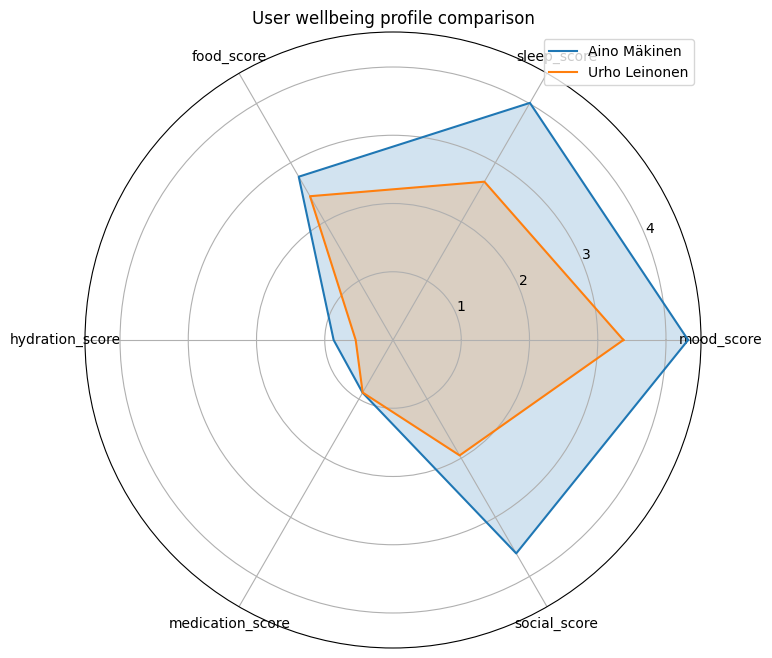

In [49]:
# otetaan mittareiden nimet radar chartia varten
labels = features

# otetaan molempien käyttäjien keskiarvot listaksi
user1_values = list(user1_means.values)
user2_values = list(user2_means.values)

# luodaan kulmat radar chartiin
angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
)

# lisätään ensimmäinen arvo uudelleen loppuun,
# jotta radar chart sulkeutuu kunnolla
user1_values.append(user1_values[0])
user2_values.append(user2_values[0])

angles = np.append(angles, angles[0])

# luodaan kuva
fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw={"polar": True}
)

# ensimmäisen käyttäjän viiva
ax.plot(
    angles,
    user1_values,
    label=user_1
)

# täytetään alue hieman läpinäkyvästi
ax.fill(
    angles,
    user1_values,
    alpha=0.2
)

# toisen käyttäjän viiva
ax.plot(
    angles,
    user2_values,
    label=user_2
)

# täytetään alue hieman läpinäkyvästi
ax.fill(
    angles,
    user2_values,
    alpha=0.2
)

# lisätään mittareiden nimet
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# otsikko
plt.title("User wellbeing profile comparison")

# legenda
plt.legend(loc="upper right")

plt.show()

## User comparison interpretation

Radar-visualisoinnin perusteella Aino Mäkisellä oli korkeammat arvot erityisesti mielialassa, unessa ja sosiaalisessa aktiivisuudessa, kun taas Urho Leinosella näkyi matalampia arvoja useilla osa-alueilla.

Tällainen analyysi voisi auttaa Welfare Botia tunnistamaan käyttäjiä, jotka saattavat tarvita enemmän tukea tai aktiivisempaa seurantaa.

## Rolling average wellbeing trend

Tarkastelen käyttäjien hyvinvoinnin pidemmän aikavälin trendiä 14 päivän rolling average - menetelmän avulla. Se tasoittaa päivittäisiä vaihteluita ja auttaa näkemään hitaasti tapahtuvia muutoksia.

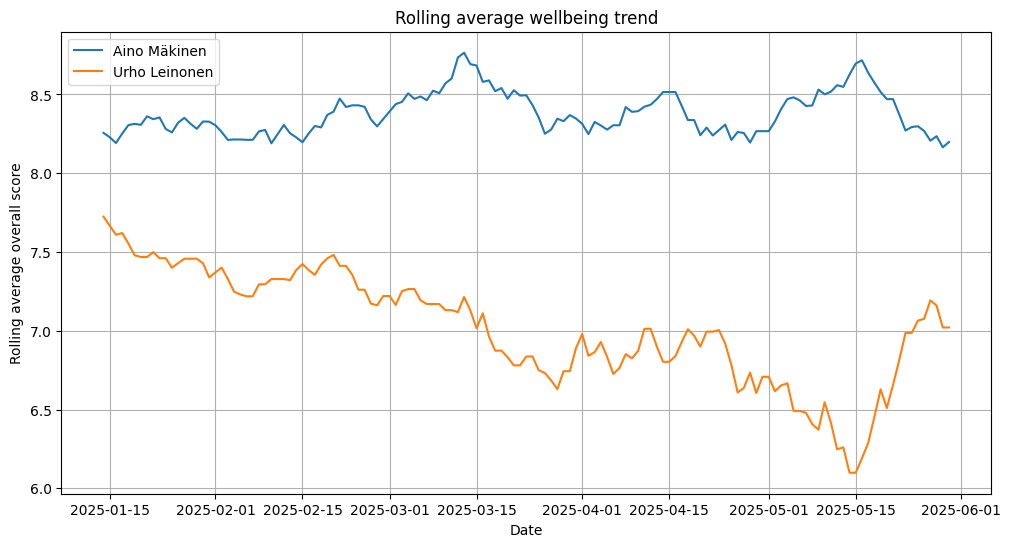

In [50]:
# lasketaan 14 päivän rolling average overall_score-arvolle
user1_data["rolling_mean"] = (
    user1_data["overall_score"]
    .rolling(14)
    .mean()
)

user2_data["rolling_mean"] = (
    user2_data["overall_score"]
    .rolling(14)
    .mean()
)

# visualisoidaan wellbeing trend
plt.figure(figsize=(12,6))

# ensimmäinen käyttäjä
plt.plot(
    user1_data["date"],
    user1_data["rolling_mean"],
    label=user_1
)

# toinen käyttäjä
plt.plot(
    user2_data["date"],
    user2_data["rolling_mean"],
    label=user_2
)

plt.title("Rolling average wellbeing trend")

plt.xlabel("Date")
plt.ylabel("Rolling average overall score")

plt.legend()

plt.grid()

plt.show()

## Kaikkien käyttäjien vertailu

In [51]:
features_all = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score",
    "overall_score"
]

user_means_all = data.groupby("user_name")[features_all].mean()

user_means_all

,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score
user_name,,,,,,,
Aino Mäkinen,4.324200,4.011933,2.762733,0.869933,0.891667,3.611000,8.378100
Eino Virtanen,3.618667,3.387800,2.175067,0.728600,0.895067,2.318267,7.282133
Lempi Korhonen,3.451133,4.059000,2.775267,0.842467,0.901600,1.753667,7.875967
Urho Leinonen,3.375867,2.678400,2.432667,0.546867,0.889133,1.952600,7.039200


## Kaikkien käyttäjien hyvinvointiprofiilien visualisointi

Tässä visualisoin kaikkien käyttäjien keskimääräiset hyvinvointimittarit pylväsdiagrammina.

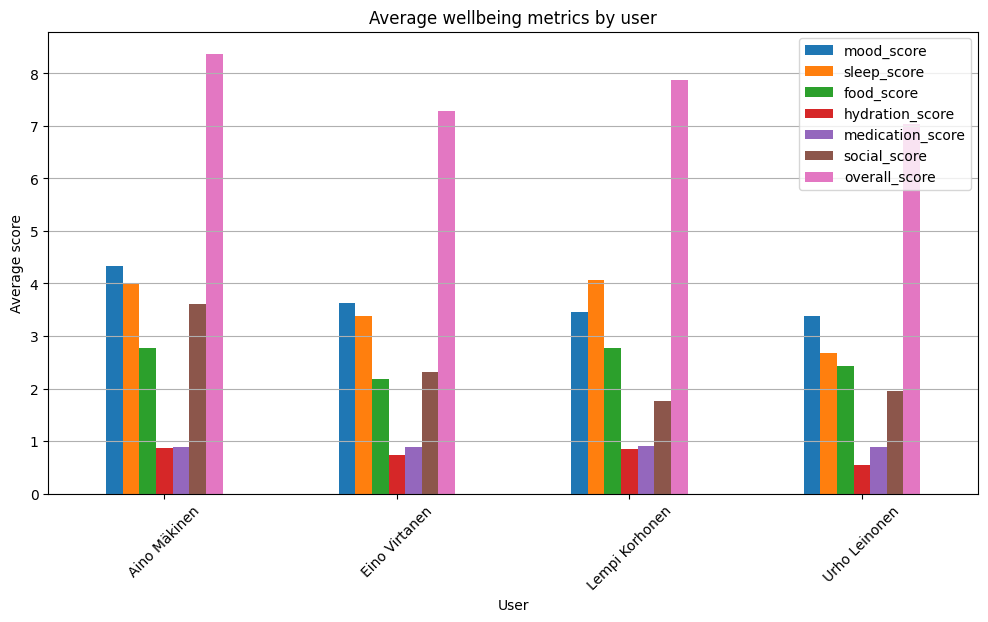

In [52]:
user_means_all.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average wellbeing metrics by user")
plt.xlabel("User")
plt.ylabel("Average score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

## Kaikkien käyttäjien vertailun tulkinta

Käyttäjien välillä näkyi selkeitä eroja hyvinvointimittareissa: osalla arvot olivat useilla osa-alueilla korkeampia, kun taas toisilla näkyi matalampia arvoja erityisesti unen, mielialan ja sosiaalisen aktiivisuuden kohdalla.

## Rolling average comparison for all users

Tarkastelen kaikkien käyttäjien pitkän aikavälin hyvinvointitrendejä rolling average -menetelmän avulla, jotta voin tunnistaa käyttäjiä, joiden hyvinvointi näyttää muuttuvan vähitellen.

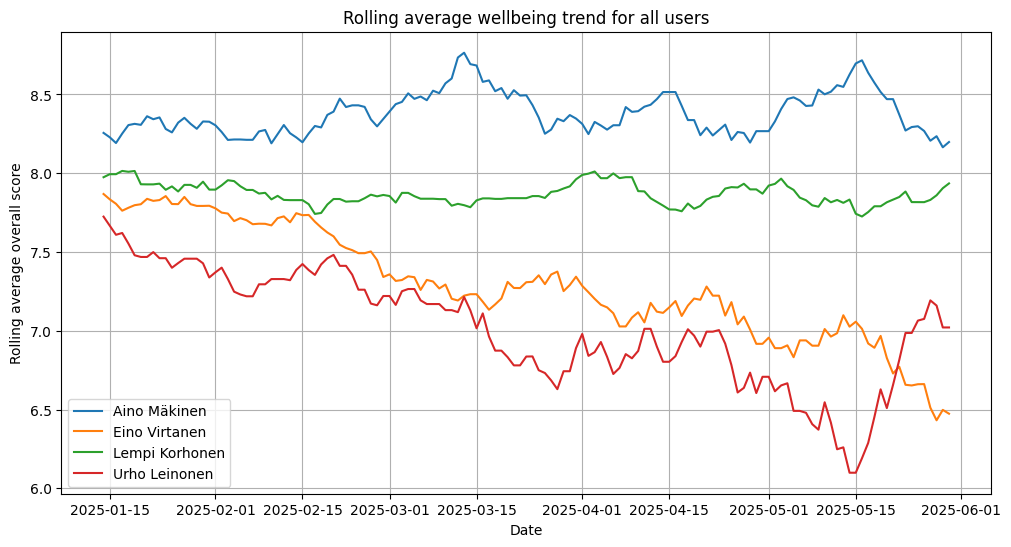

In [55]:
# luodaan kuva
plt.figure(figsize=(12,6))

# käydään kaikki käyttäjät läpi
for user in data["user_name"].unique():

    # otetaan yhden käyttäjän data
    user_data = data[
        data["user_name"] == user
    ].copy()

    # lasketaan rolling average
    user_data["rolling_mean"] = (
        user_data["overall_score"]
        .rolling(14)
        .mean()
    )

    # piirretään trendi
    plt.plot(
        user_data["date"],
        user_data["rolling_mean"],
        label=user
    )

plt.title("Rolling average wellbeing trend for all users")

plt.xlabel("Date")
plt.ylabel("Rolling average overall score")

plt.legend()

plt.grid()

plt.show()

## Rolling average comparison interpretation

Käyttäjien hyvinvointitrendeissä näkyi eroja pitkällä aikavälillä: osalla overall_score pysyi vakaampana, kun taas toisilla näkyi enemmän vaihtelua tai hitaasti laskevia trendejä.

Tällainen analyysi voisi auttaa Welfare Botia tunnistamaan käyttäjiä, joiden hyvinvointi muuttuu vähitellen ajan myötä.